In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
from shapely.geometry import box
import fiona
import pyproj

In [86]:
#uploading building height file (ended up not using and opting for documents) 
building_height = gpd.read_file("building_foot_print_height_UW.gpkg")

In [87]:
# 10 km resolution of precipitation mm across uw campus. Satellite data

precip_mm = pd.read_csv('IMERG_CSV/pixel_5.csv') 
precip_mm['time'] = pd.to_datetime(precip_mm['time_utc'], utc=True)
precip_mm['year'] = precip_mm['time'].dt.year

precip_yearly = precip_mm.groupby('year')['precip_mm'].mean()
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

precip_mm['season'] = precip_mm['time'].dt.month.map(season_map)
precip_seasons = precip_mm.groupby('season')['precip_mm'].mean()

precip_mm = precip_mm.drop(columns=['.geo', 'time_utc'])
precip_mm = precip_mm.set_index('time')
precip_mm
# Monthly accumulated precipitation (sum of hourly mm)
#monthly_totals = precip_mm['precip_mm'].resample('ME').sum()

# Average monthly precipitation across all years (2000–2024)
#monthly_avg = monthly_totals.groupby(monthly_totals.index.month).mean()

yearly_totals = precip_mm['precip_mm'].resample('YE').sum()
yearly_avg = yearly_totals.mean()
yearly_avg

precip_mm.iloc[:,1:]

,lat_center,lon_center,pixel_id,pixel_num,precip_mm,year,season
time,,,,,,,
2000-06-01 00:00:00+00:00,47.65,-122.35,pixel_5,5,0.043,2000,Summer
2000-06-01 01:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2000,Summer
2000-06-01 02:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2000,Summer
2000-06-01 03:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2000,Summer
2000-06-01 04:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2000,Summer
...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2024,Winter
2024-12-31 20:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2024,Winter
2024-12-31 21:00:00+00:00,47.65,-122.35,pixel_5,5,0.000,2024,Winter


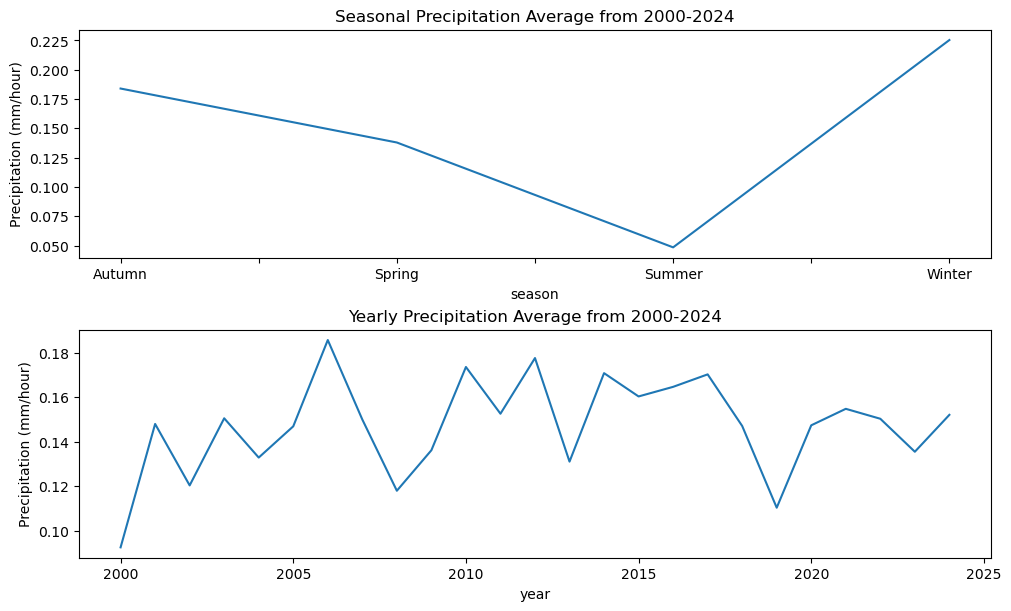

In [88]:
# Analyzing Precipitation Trends looking at seasonal and yearly trends
fig, axs = plt.subplots(2,1, figsize=(10, 6), layout='constrained')
precip_seasons.plot(ax=axs[0])
precip_yearly.plot(ax=axs[1])
axs[0].set_title('Seasonal Precipitation Average from 2000-2024')
axs[0].set_ylabel('Precipitation (mm/hour)')
axs[1].set_title('Yearly Precipitation Average from 2000-2024')
axs[1].set_ylabel('Precipitation (mm/hour)')
fig.savefig('Seasonal_Yearly_Precipitation.png', dpi=300)
plt.show()

In [89]:
# Analyzing trends in seasonal differences 
precip_mm.groupby('season')['precip_mm'].describe().round(2)


#Checking standard deviation is worse in some seasons??

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Autumn,54600.0,0.18,0.62,0.0,0.0,0.0,0.03,16.23
Spring,52992.0,0.14,0.45,0.0,0.0,0.0,0.00,13.48
Summer,55200.0,0.05,0.24,0.0,0.0,0.0,0.00,11.94
Winter,52728.0,0.23,0.77,0.0,0.0,0.0,0.05,24.08


In [90]:
#Make sure areas are reasonable 


mc_area = (14610 * 0.092903) + (13225 * 0.092903) + (12430 * 0.092903) + (9420  * 0.092903) + (8665 * 0.092903)
mc_height = 58 * .092903   #One building is actually 48 feet but ignore for now and this is also dependent on using roof for capture
ls_area = 18345 * .092903
ls_height = 92 * .092903
hs_area = 16740 * .092903
hs_height = 72 * .092903
IEB_area = 1193.43   #m^2
IEB_height = 67  * .092903
husky_area =  59000 * .092903  #only using north estimate
husky_height = 169 * .092903






In [91]:
# Rainfall Intensity is precip / time 

#daily_avg = precip_mm.groupby(precip_mm['time'].dt.date)['precip_mm'].mean()
#RI = (daily_avg/24)/1000 / (60 * 60)   #m/sec
# Would it be so much better to do rainfall intensity of m/sec not per day but then take average of Q per day. 
precip_mm['intensity_m_hr'] = (precip_mm['precip_mm'] / (1000))
precip_mm['intensity_m_hr'].max()

np.float64(0.024084999084472657)

In [98]:
# Calculate flow rate 
# Q = coeff * rainfall intensity * A
# coeff for impervious roof =0.95

precip_mm['Q_IEB'] = (precip_mm['intensity_m_hr'] * 0.95 * IEB_area) / (60*60)
precip_mm['Q_mc'] = (precip_mm['intensity_m_hr'] * 0.95 * mc_area) / (60*60)
precip_mm['Q_husky'] = (precip_mm['intensity_m_hr'] * 0.95 * husky_area) / (60*60)

Q_IEB = (precip_mm['intensity_m_hr'] * 0.95 * IEB_area) / (60*60)
Q_mc = (precip_mm['intensity_m_hr'] * 0.95 * mc_area) / (60*60)
#Q_ls = (precip_mm['intensity_m_hr'] * 0.95 * ls_area) / (60*60)
#Q_hs = (precip_mm['intensity_m_hr'] * 0.95 * hs_area) / (60*60)
Q_husky = (precip_mm['intensity_m_hr'] * 0.95 * husky_area) / (60*60)

buildings = {
    "IEB": 'Q_IEB',
    "MC": 'Q_mc',
    "Husky": 'Q_husky'
}


# Calculate the power from each roof area whether open channel or penstock
# 60 percent turbine efficency 
# p = rho * g * net head * flow rate * turbine efficency (eta_t)
# stop and go issues with running. Spring months might be a lot of stop and go.
rho = 1000     #kg/m^3
g = 9.81       #m/s
# Differeng Hn depending on building can use 20 ft 
# Differing flow depending on building 
eta_t = .60    #60% efficency 
#P = rho * g * 6.1 * Q_IEB * 0.60
H = 6.1
results = {}

for name, q_col in buildings.items():
    Q = precip_mm[q_col]

    P = (rho * g * H * Q * eta_t) / 1000  # KW

    precip_mm[f"P_{name}"] = P
    results[name] = P

    print(name, "max instantenous power KW:", P.max().round(2))




yearly_p = P.resample('YE').sum()




IEB max instantenous power KW: 0.27
MC max instantenous power KW: 1.24
Husky max instantenous power KW: 1.25


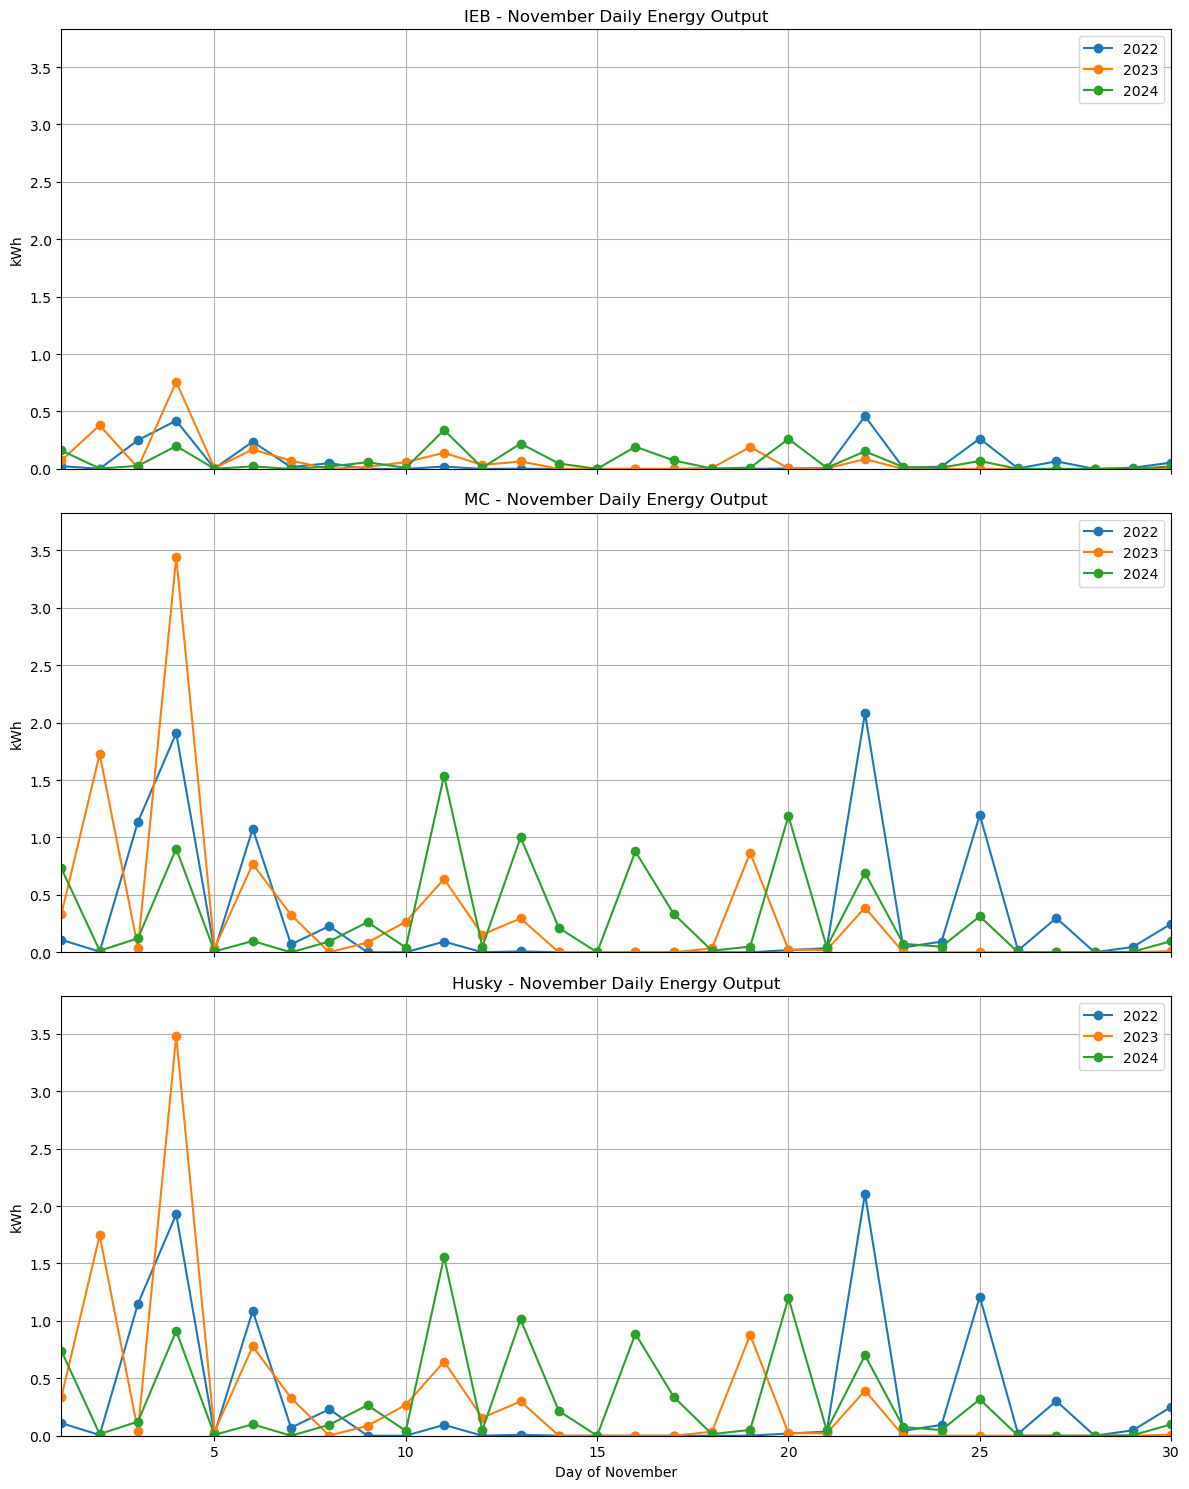

In [45]:
dt_hours = 1
power_cols = [col for col in precip_mm.columns if col.startswith("P_")]

for col in power_cols:
    precip_mm[f"E_{col[2:]}"] = precip_mm[col] * dt_hours
november = precip_mm[precip_mm.index.month == 11]
daily_kwh_nov = (
    november[[col for col in november.columns if col.startswith("E_")]]
    .resample("D")
    .sum()
)


# Years to compare
years = [2022, 2023, 2024]

# Find global ymax across all buildings and years
ymax = max(
    daily_kwh_nov[f'E_{building}'].loc[f'{year}-11'].max()
    for building in buildings.keys()
    for year in years
)

# Create subplots
fig, axes = plt.subplots(
    len(buildings),
    1,
    figsize=(12, 15),
    sharex=True,
    sharey=True
)

# Loop through buildings
for ax, building in zip(axes, buildings.keys()):

    # Plot each year on SAME November day axis
    for year in years:

        data = daily_kwh_nov[f'E_{building}'].loc[f'{year}-11']

        # Use day of month for x-axis
        ax.plot(
            data.index.day,
            data.values,
            marker='o',
            label=str(year)
        )

    ax.set_title(f'{building} - November Daily Energy Output')
    ax.set_ylabel('kWh')
    ax.set_ylim(0, ymax * 1.1)
    ax.set_xlim(1, 30)
    ax.grid(True)
    ax.legend()

# Shared x-axis
axes[-1].set_xlabel('Day of November')

plt.tight_layout()
plt.show()
fig.savefig('November Daily Energy Output', dpi=300)


In [97]:
#Finding kwh of november and yearly 

year_22 = 2022
year_23 = 2023
year_24 = 2024
nov_kwh_2022 = daily_kwh_nov.loc[f'{year_22}-11']
nov_kwh_2023 = daily_kwh_nov.loc[f'{year_23}-11']
nov_kwh_2024 = daily_kwh_nov.loc[f'{year_24}-11']

print(nov_kwh_2022.iloc[:,0].sum().round(2))
print(nov_kwh_2023.iloc[:,1].sum().round(2))
print(nov_kwh_2024.iloc[:,2].sum().round(2))


dt_hours = 1
power_cols = [col for col in precip_mm.columns if col.startswith("P_")]

for col in power_cols:
    precip_mm[f"E_{col[2:]}"] = precip_mm[col] * dt_hours


energy_cols = [col for col in precip_mm.columns if col.startswith("E_")]

yearly_kwh = (
    precip_mm[energy_cols]
    .resample("YE")
    .sum()
)

# Use year as index instead of Dec-31 timestamps
yearly_kwh.index = yearly_kwh.index.year

print(yearly_kwh.iloc[yearly_kwh.index.get_loc(2024), 1:2].round(2))

1.92
9.46
8.91
E_MC    68.58
Name: 2024, dtype: float64
